### **Libraries**

In [ ]:
!pip install osmnx geopandas matplotlib
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 3.0 MB/s eta 0:00:00


## Data Processing

### Place Definition

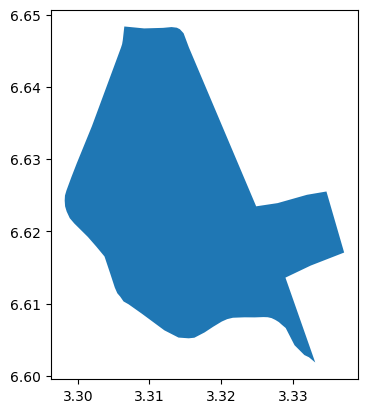

In [ ]:
# Define the place
place = "Agege, Lagos, Nigeria"

# Get the GeoDataFrame for the place
gdf = ox.geocoder.geocode_to_gdf(place)

# Plot the GeoDataFrame
gdf.plot()
plt.show()

In [ ]:
!pip install folium matplotlib mapclassify
gdf.explore()

### identifying highways, buildings, railways, schools and amenities

In [ ]:
tags = {
    'building': True,
    'highway': True,
    'railway': True,
    'amenity': ['kindergarten', 'school', 'university', 'hospital', 'clinic', 'library']
}


/tmp/ipython-input-3621741617.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab_colors = cm.get_cmap('tab20', 20)
/tmp/ipython-input-3621741617.py:89: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


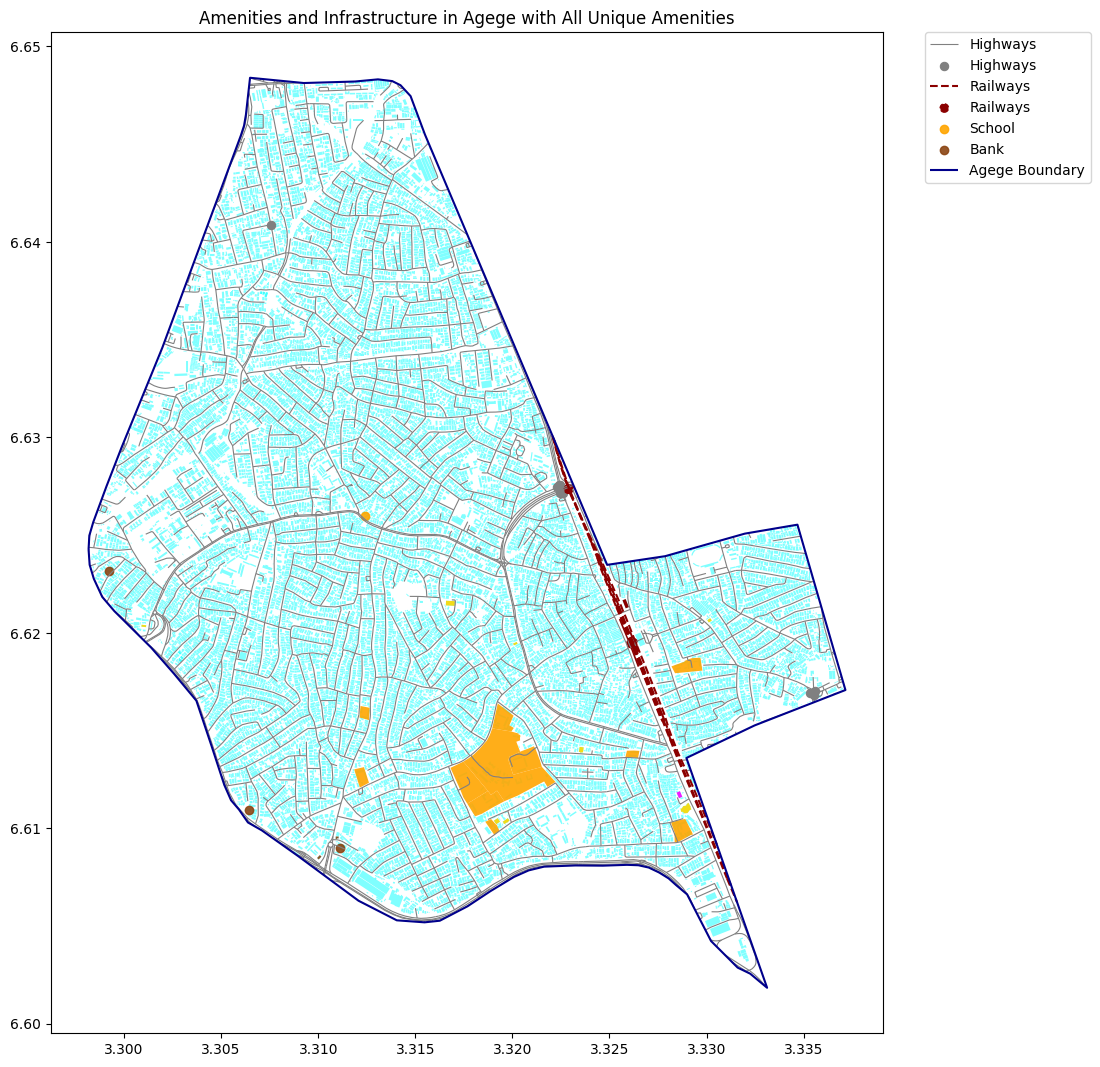

In [ ]:
# Define the place of interest
place = "Agege, Lagos, Nigeria"

# Get the boundary polygon for Agege
boundary = ox.geocode_to_gdf(place)

# Define the tags to fetch various features, including amenities, buildings, highways, and railways.
# The amenity list includes common types, but the code will dynamically assign colors to any unique amenity found.
tags_for_fetch = {
    'building': True,
    'highway': True,
    'railway': True,
    'amenity': [
        'kindergarten', 'school', 'university', 'hospital', 'clinic', 'library',
        'bank', 'community_centre', 'place_of_worship' # Including amenities previously identified
    ]
}

# Download features from OpenStreetMap
features = ox.features_from_place(place, tags_for_fetch)

# Clip features to the Agege boundary to ensure all data is within the defined area
features_clipped = gpd.clip(features, boundary)

# Initialize amenity_colors with some predefined colors for known amenity types.
# This dictionary will be dynamically expanded for any other unique amenities found in features_clipped.
amenity_colors = {
    'kindergarten': 'red',
    'school': 'orange',
    'university': 'purple',
    'hospital': 'darkgreen',
    'clinic': 'green',
    'library': 'darkblue',
    'bank': 'saddlebrown',
    'community_centre': 'magenta',
    'place_of_worship': 'gold',
}

# Get all unique amenity types from the clipped data that actually exist
unique_amenities_in_data = []
if 'amenity' in features_clipped.columns:
    unique_amenities_in_data = features_clipped['amenity'].dropna().unique()

# Dynamically assign colors to any unique amenity found that doesn't have a predefined color.
# A qualitative colormap ('tab20') is used to ensure distinct colors.
tab_colors = cm.get_cmap('tab20', 20)
color_index = 0
for amenity in unique_amenities_in_data:
    if amenity not in amenity_colors:
        amenity_colors[amenity] = mcolors.to_hex(tab_colors(color_index % 20))
        color_index += 1

# Set up the plot
fig, ax = plt.subplots(figsize=(13, 13))

# Plot buildings
if 'building' in features_clipped.columns:
    buildings_to_plot = features_clipped[features_clipped['building'].notna()]
    if not buildings_to_plot.empty:
        buildings_to_plot.plot(ax=ax, color='cyan', alpha=0.5, label='Buildings')

# Plot highways
if 'highway' in features_clipped.columns:
    highways_to_plot = features_clipped[features_clipped['highway'].notna()]
    if not highways_to_plot.empty:
        highways_to_plot.plot(ax=ax, color='gray', linewidth=0.8, label='Highways')

# Plot railways
if 'railway' in features_clipped.columns:
    railways_to_plot = features_clipped[features_clipped['railway'].notna()]
    if not railways_to_plot.empty:
        railways_to_plot.plot(ax=ax, color='darkred', linestyle='--', label='Railways')

# Plot each unique amenity type with its assigned distinct color
if 'amenity' in features_clipped.columns:
    for amenity_type in unique_amenities_in_data:
        color = amenity_colors.get(amenity_type, 'grey') # Get assigned color, with 'grey' as a fallback
        subset = features_clipped[features_clipped['amenity'] == amenity_type]
        if not subset.empty:
            subset.plot(ax=ax, color=color, alpha=0.9, label=amenity_type.title())

# Plot the Agege boundary
boundary.boundary.plot(ax=ax, color='darkblue', linewidth=1.5, label='Agege Boundary')

# Set the title for the plot
plt.title('Amenities and Infrastructure in Agege with All Unique Amenities')

# Adjust legend position to avoid overlapping with the map and make it clearly visible
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Display the plot
plt.show()

### identifying the kindergartens and the places of worship

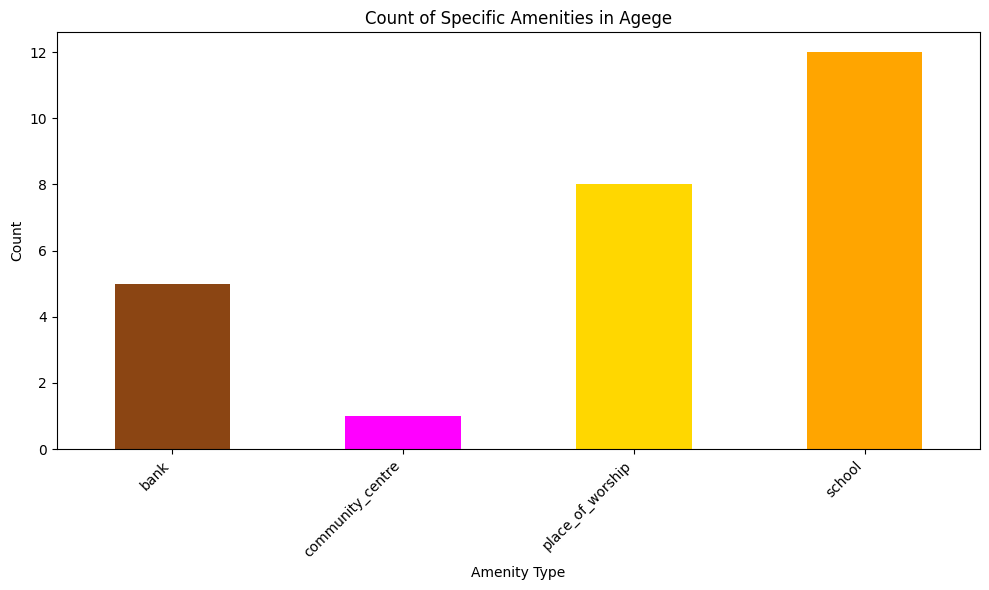

In [ ]:
# prompt: create a chart of Types of amenities found

import matplotlib.pyplot as plt
# Filter features for only amenity types defined in amenity_colors
amenities_of_interest = features_clipped[features_clipped['amenity'].isin(list(amenity_colors.keys()))].copy()

# Count the occurrences of each amenity type
amenity_counts = amenities_of_interest['amenity'].value_counts()

# Create a bar chart
plt.figure(figsize=(10, 6))
amenity_counts.sort_index().plot(kind='bar', color=[amenity_colors.get(x, 'grey') for x in amenity_counts.sort_index().index])
plt.title('Count of Specific Amenities in Agege')
plt.xlabel('Amenity Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

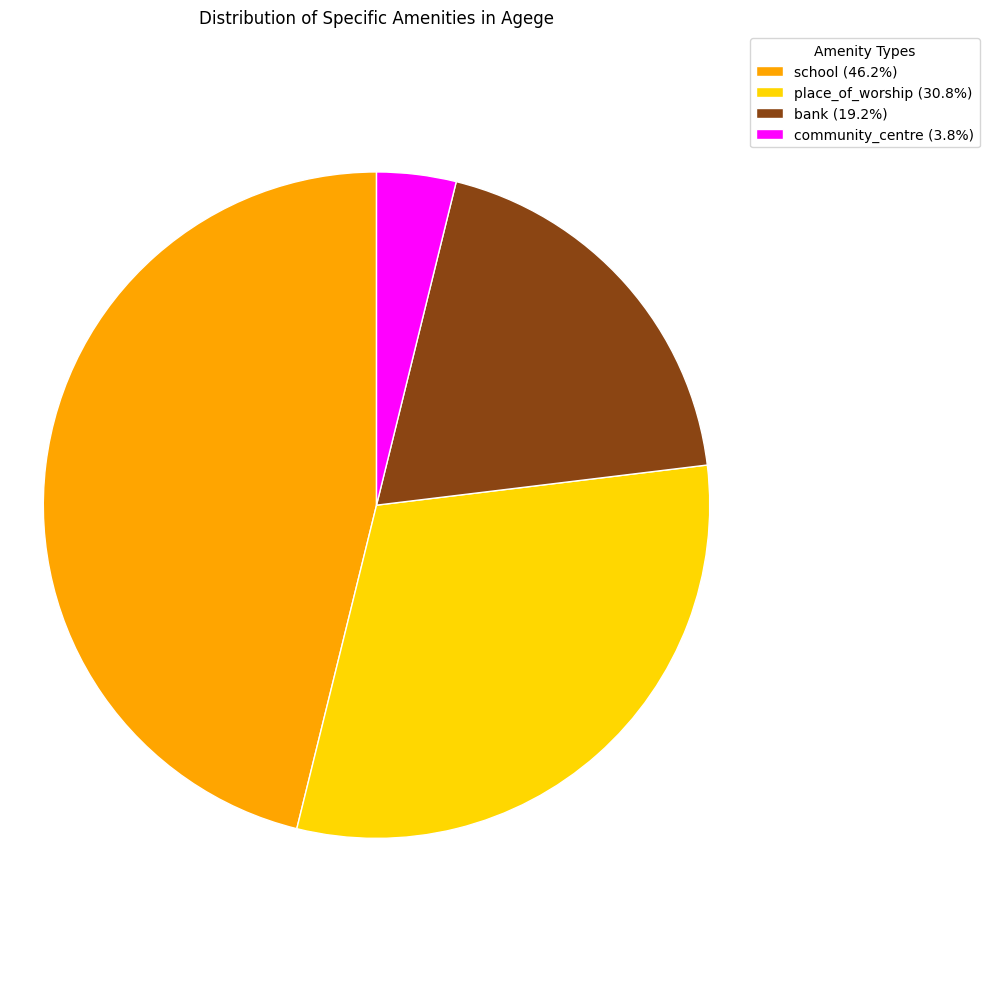

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the pie chart
fig, ax = plt.subplots(figsize=(10, 10)) # Increased figure size for better spacing

# Plot the pie chart and capture wedges and texts (autotexts are not returned when autopct=None)
wedges, texts = ax.pie(
    amenity_counts, # Data from the kernel state
    autopct=None, # No percentage labels around the pie itself
    startangle=90,
    colors=[amenity_colors.get(x, 'grey') for x in amenity_counts.index], # Colors from kernel state
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'} # Optional: for better visual separation
)

# Calculate percentages for the legend
total_amenities = amenity_counts.sum()
legend_labels = []
for amenity_type, count in amenity_counts.items():
    percentage = (count / total_amenities) * 100
    if percentage > 0:
        legend_labels.append(f"{amenity_type} ({percentage:.1f}%)")
    else:
        legend_labels.append(f"{amenity_type} (0.0%)")

# Add legend outside the plot area to avoid overlap with the pie or labels
ax.legend(
    wedges,
    legend_labels, # Use the new labels with percentages
    title="Amenity Types",
    loc="upper left", # Position the legend at the top right of the axis
    bbox_to_anchor=(1, 1) # Position relative to the top right corner of the plot area
)

ax.set_title('Distribution of Specific Amenities in Agege')
ax.set_ylabel('') # Hide the default y-label
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout() # Adjust layout to prevent labels/legend from overlapping
plt.show()

In [ ]:
# Print summary statistics
print("Summary of features found:")
print("-" * 50)

if 'building' in features.columns:
    building_count = features['building'].notna().sum()
    print(f"Buildings: {building_count}")

if 'highway' in features.columns:
    highway_count = features['highway'].notna().sum()
    print(f"Highways/Roads: {highway_count}")

if 'railway' in features.columns:
    railway_count = features['railway'].notna().sum()
    print(f"Railways: {railway_count}")

if 'amenity' in features.columns:
    school_count = features['amenity'].isin(['school', 'university', 'kindergarten']).sum()
    print(f"Schools and educational facilities: {school_count}")

# Get all unique amenities
if 'amenity' in features.columns:
    print("\nTypes of amenities found:")
    print("-" * 50)
    amenities = features[features['amenity'].notna()]['amenity'].unique()
    for amenity in sorted(amenities):
        count = features[features['amenity'] == amenity].shape[0]
        print(f"{amenity}: {count}")

Summary of features found:
--------------------------------------------------
Buildings: 25979
Highways/Roads: 1208
Railways: 32
Schools and educational facilities: 12

Types of amenities found:
--------------------------------------------------
bank: 5
community_centre: 1
place_of_worship: 8
school: 12
